### Probability of Success Reversal (Reversal 2.3.2)

### QQQ-Only Universe Builder

In [2]:
import pandas as pd
from pathlib import Path
from reversal_universe import build_named_universe_map

MIN_UNIVERSE_MARKET_CAP = 1e9
MIN_UNIVERSE_PRICE = 10.0
SPY_TICKERS_PATH = Path.cwd() / "spy_tickers.txt"
QQQ_TICKERS_PATH = Path.cwd() / "qqq_tickers.txt"
UNIVERSE_SAVE_PATH = Path.cwd() / "qqq_only_filtered_tickers.csv"

universe_presets = build_named_universe_map(
    min_market_cap=MIN_UNIVERSE_MARKET_CAP,
    min_price=MIN_UNIVERSE_PRICE,
    spy_tickers_path=SPY_TICKERS_PATH,
    qqq_tickers_path=QQQ_TICKERS_PATH,
)
qqq_only_filtered = universe_presets["qqq_only_filtered"]
universe_df = pd.DataFrame({"ticker": qqq_only_filtered})
universe_df.to_csv(UNIVERSE_SAVE_PATH, index=False)

print(f"qqq_only_filtered usable tickers: {len(qqq_only_filtered)}")
print(f"Saved -> {UNIVERSE_SAVE_PATH}")
display(universe_df.head(20))


qqq_only_filtered usable tickers: 97
Saved -> /Users/mac/Documents/New project/qqq_only_filtered_tickers.csv


,ticker
0,AAPL
1,ABNB
2,ADBE
3,ADI
4,ADP
5,ADSK
6,AEP
7,ALNY
8,AMAT
9,AMD


### QQQ Universe Data Refresh

In [3]:
from pathlib import Path
from update_reversal_data import refresh_reversal_data

DATA_REFRESH_START_DATE = "2024-01-01"
DATA_REFRESH_SKIP_EXISTING = True
DATA_REFRESH_DIR = Path.cwd() / "reversal_data"

refresh_summary_df = refresh_reversal_data(
    tickers=qqq_only_filtered,
    start_date=DATA_REFRESH_START_DATE,
    data_dir=DATA_REFRESH_DIR,
    skip_existing=DATA_REFRESH_SKIP_EXISTING,
)

print(refresh_summary_df["status"].value_counts(dropna=False).to_string())
display(refresh_summary_df.head(20))


status
skipped_existing    97


,ticker,status,rows,path
0,AAPL,skipped_existing,<NA>,/Users/mac/Documents/New project/reversal_data...
1,ABNB,skipped_existing,<NA>,/Users/mac/Documents/New project/reversal_data...
2,ADBE,skipped_existing,<NA>,/Users/mac/Documents/New project/reversal_data...
3,ADI,skipped_existing,<NA>,/Users/mac/Documents/New project/reversal_data...
4,ADP,skipped_existing,<NA>,/Users/mac/Documents/New project/reversal_data...
5,ADSK,skipped_existing,<NA>,/Users/mac/Documents/New project/reversal_data...
6,AEP,skipped_existing,<NA>,/Users/mac/Documents/New project/reversal_data...
7,ALNY,skipped_existing,<NA>,/Users/mac/Documents/New project/reversal_data...
8,AMAT,skipped_existing,<NA>,/Users/mac/Documents/New project/reversal_data...
9,AMD,skipped_existing,<NA>,/Users/mac/Documents/New project/reversal_data...


### Backtest Update Note

Reversal 2.3.2 uses a staggered backtest entry rule: at most one new ticker per day, target 50% portfolio allocation per new position, and at most two concurrent tickers. Universe comparison is handled by `compare_reversal_2_3_1_universes.py`.

Before running the analysis cells below on a fresh machine, run the QQQ universe data-refresh cell once to populate `reversal_data/` for the current `qqq_only_filtered` usable-ticker list.

Running reversal analysis from CSV files...


===== AAPL results =====
Signal Date  Window N  Max Drop %  Recover %  Success?
 2026-02-12         1        5.56      13.38     False
 2026-02-12         2        5.56      39.88     False
 2026-02-12         3        5.56      43.34     False
 2026-02-12         4        5.56      43.34     False
Signal days: 12   Success rate: 66.7%

===== ABNB results =====
Signal Date  Window N  Max Drop %  Recover %  Success?
 2026-03-02         1        4.83      87.58      True
 2026-03-02         2        4.83     143.33      True
 2026-03-02         3        4.83     159.66      True
 2026-03-02         4        4.83     159.66      True
Signal days: 33   Success rate: 51.5%

===== ADBE results =====
Signal Date  Window N  Max Drop %  Recover %  Success?
 2026-03-10         1        4.98      85.36      True
 2026-03-10         2        4.98      85.36      True
Signal days: 30   Success rate: 50.0%

===== ADI results =====
Signal Date  Window N  

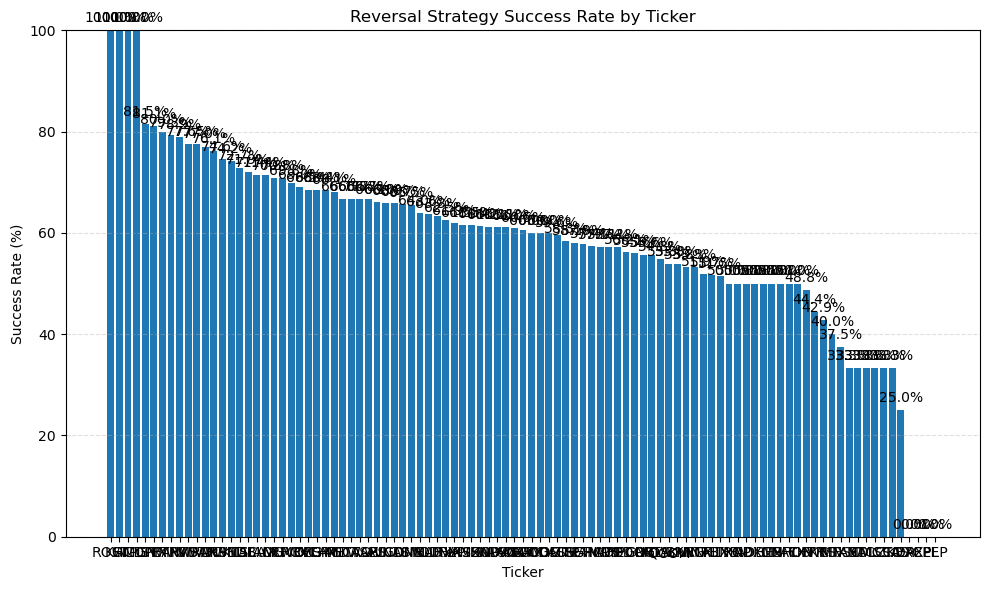

In [4]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------- USER CONFIG ----------------
BASE_DIR         = Path.cwd()
DATA_DIR         = BASE_DIR / "reversal_data"

TICKERS          = qqq_only_filtered
DROP_THR         = 0.04            # >= 4% intraday drop triggers a signal
RECOVER_TARGET   = 0.7             # >= 70% recovery judged "success"
LOOKAHEAD        = [1, 2, 3, 4]    # T+N trading-day windows

SAVE_PLOT        = True
PLOT_PATH        = BASE_DIR / "success_rate_comparison.png"
# ------------------------------------------


def load_ticker_csv(ticker: str, data_dir: Path) -> pd.DataFrame:
    file_path = data_dir / f"{ticker}.csv"
    if not file_path.exists():
        raise FileNotFoundError(f"{ticker}: file not found -> {file_path}")

    df = pd.read_csv(file_path)

    # 清洗列名
    df.columns = (
        df.columns
        .str.replace(r'[\xa0\u3000\t]', ' ', regex=True)
        .str.strip()
    )

    # 转换类型
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    for col in ["Open", "High", "Low", "Adj Close", "Max Drop"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # 保持你原策略逻辑：分析前先升序，再算 Prev Close
    df = df.sort_values("Date").reset_index(drop=True)
    df["Prev Close"] = df["Adj Close"].shift(1).fillna(df["Adj Close"])

    return df


def analyze(df: pd.DataFrame, name: str):
    signals = df[df["Max Drop"] >= DROP_THR].copy()
    rows = []

    for idx, row in signals.iterrows():
        prev_close = row["Prev Close"]
        low_today = row["Low"]

        # 你的原策略逻辑，不改
        fall_amt = row["Max Drop"] * prev_close
        # fall_amt = prev_close - low_today   # alternate formula
        if fall_amt <= 0 or np.isnan(fall_amt):
            continue

        for N in LOOKAHEAD:
            if idx + N >= len(df):
                break

            high_n = df.loc[idx + 1: idx + N, "High"].max()
            recover_ratio = (high_n - low_today) / fall_amt

            rows.append({
                "Signal Date": row["Date"].date(),
                "Window N": N,
                "Max Drop %": round(row["Max Drop"] * 100, 2),
                "Recover %": round(recover_ratio * 100, 2),
                "Success?": recover_ratio >= RECOVER_TARGET,
            })

    result = pd.DataFrame(rows)

    success_rate = (
        result.groupby("Signal Date")["Success?"].any().mean() * 100
        if not result.empty else 0
    )

    print(f"\n===== {name} results =====")

    if result.empty:
        print("No qualifying signals found.")
        print("Signal days: 0   Success rate: 0.0%")
        return {
            "ticker": name,
            "signal_days": 0,
            "success_rate": 0.0,
            "result": result
        }

    # 只显示最近一个 signal day
    latest_date = result["Signal Date"].max()
    recent_rows = result[result["Signal Date"] == latest_date]
    recent_rows = recent_rows.sort_values("Window N")

    print(recent_rows.to_string(index=False))
    print(f"Signal days: {result['Signal Date'].nunique()}   "
          f"Success rate: {success_rate:.1f}%")

    return {
        "ticker": name,
        "signal_days": int(result["Signal Date"].nunique()),
        "success_rate": float(success_rate),
        "result": result
    }


def plot_success_rates(summary_df: pd.DataFrame, save_plot: bool = True, plot_path: Path | None = None):
    if summary_df.empty:
        print("\nNo summary data to plot.")
        return

    plot_df = summary_df.sort_values("success_rate", ascending=False).reset_index(drop=True)

    plt.figure(figsize=(10, 6))
    bars = plt.bar(plot_df["ticker"], plot_df["success_rate"])

    plt.title("Reversal Strategy Success Rate by Ticker")
    plt.xlabel("Ticker")
    plt.ylabel("Success Rate (%)")
    plt.ylim(0, 100)
    plt.grid(axis="y", linestyle="--", alpha=0.4)

    # 在柱子上方标注数值
    for bar, rate in zip(bars, plot_df["success_rate"]):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f"{rate:.1f}%",
            ha="center",
            va="bottom",
            fontsize=10
        )

    plt.tight_layout()

    if save_plot and plot_path is not None:
        plt.savefig(plot_path, dpi=150, bbox_inches="tight")
        print(f"\nSaved plot -> {plot_path}")

    plt.show()


def main():
    print("Running reversal analysis from CSV files...\n")

    summary_rows = []

    for ticker in TICKERS:
        try:
            df = load_ticker_csv(ticker, DATA_DIR)
            out = analyze(df, ticker)

            summary_rows.append({
                "ticker": out["ticker"],
                "signal_days": out["signal_days"],
                "success_rate": out["success_rate"]
            })

        except Exception as e:
            print(f"{ticker}: failed -> {e}")

    summary_df = pd.DataFrame(summary_rows)

    if not summary_df.empty:
        print("\n===== Summary =====")
        print(summary_df.sort_values("success_rate", ascending=False).to_string(index=False))

    plot_success_rates(summary_df, save_plot=SAVE_PLOT, plot_path=PLOT_PATH)


if __name__ == "__main__":
    main()

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
from pathlib import Path

# ========= LIVE REVERSAL SCREENER (Reversal 2.3.2) =========
# 输入一个 ticker 或多个 ticker；程序会：
# 1) 抓取当前近实时价格（Yahoo Finance，可能有延迟）；大 universe 请先用上面的 universe builder 缩小范围
# 2) 计算相对昨日收盘的当前跌幅
# 3) 用“回补当天跌幅的 x%”作为反弹目标，而不是“股价直接上涨 x%”
# 4) 在过去 OBS_WINDOW 个交易日中，寻找历史上“至少这么跌”的 signal day
# 5) 统计未来 N 个交易日内，历史上有多少次能回补该 signal-day 跌幅的 x%

LIVE_TICKERS = qqq_only_filtered
TARGET_BOUNCE_PCT = 0.70        # recover x% of the signal-day drop, same meaning as Part 1
FORWARD_DAYS = 5                # future N trading days
OBS_WINDOW = 252                # use the latest OBS_WINDOW trading days as the historical observation window
MIN_CALL_SUCCESS_RATE = 80.0    # your call-entry watch threshold
SHOW_TOP_MATCHES = True
TOP_MATCHES_TO_SHOW = 8

DATA_DIR = Path.cwd() / "reversal_data"
# ===========================================================


def _normalize_tickers(tickers):
    if isinstance(tickers, str):
        tickers = [tickers]
    return [str(t).strip().upper() for t in tickers if str(t).strip()]


def _clean_yf_columns(df: pd.DataFrame) -> pd.DataFrame:
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    return df


def load_reversal_csv(ticker: str, data_dir: Path = DATA_DIR) -> pd.DataFrame:
    file_path = data_dir / f"{ticker}.csv"
    if not file_path.exists():
        raise FileNotFoundError(f"{ticker}: file not found -> {file_path}")

    df = pd.read_csv(file_path)
    df.columns = (
        df.columns
        .str.replace(r'[ 　	]', ' ', regex=True)
        .str.strip()
    )

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    for col in ["Open", "High", "Low", "Adj Close", "Max Drop"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.sort_values("Date").reset_index(drop=True)
    df["Prev Close"] = df["Adj Close"].shift(1).fillna(df["Adj Close"])
    return df


def get_live_snapshot(ticker: str) -> dict:
    intraday = yf.download(
        ticker,
        period="5d",
        interval="1m",
        auto_adjust=False,
        progress=False,
        threads=False,
        prepost=False,
    )
    daily = yf.download(
        ticker,
        period="10d",
        interval="1d",
        auto_adjust=False,
        progress=False,
        threads=False,
    )

    intraday = _clean_yf_columns(intraday)
    daily = _clean_yf_columns(daily)

    if intraday.empty or "Close" not in intraday.columns:
        raise ValueError(f"{ticker}: unable to fetch recent intraday price.")
    if daily.empty or "Close" not in daily.columns:
        raise ValueError(f"{ticker}: unable to fetch recent daily close data.")

    intraday_close = pd.to_numeric(intraday["Close"], errors="coerce").dropna()
    daily_close = pd.to_numeric(daily["Close"], errors="coerce").dropna()

    if intraday_close.empty:
        raise ValueError(f"{ticker}: intraday Close series is empty.")
    if daily_close.empty:
        raise ValueError(f"{ticker}: daily Close series is empty.")

    current_price = float(intraday_close.iloc[-1])
    asof = pd.Timestamp(intraday_close.index[-1])
    asof_date = asof.date()

    daily_dates = pd.to_datetime(daily_close.index)
    if len(daily_close) >= 2 and daily_dates[-1].date() == asof_date:
        prev_close = float(daily_close.iloc[-2])
    else:
        prev_close = float(daily_close.iloc[-1])

    if prev_close <= 0:
        raise ValueError(f"{ticker}: previous close is non-positive.")

    current_drop_amount = max(prev_close - current_price, 0.0)
    current_drop_pct = current_drop_amount / prev_close if prev_close > 0 else np.nan
    target_rebound_amount = current_drop_amount * TARGET_BOUNCE_PCT
    target_price = current_price + target_rebound_amount

    return {
        "ticker": ticker,
        "asof": asof,
        "current_price": current_price,
        "prev_close": prev_close,
        "current_drop_amount": current_drop_amount,
        "current_drop_pct": current_drop_pct,
        "target_rebound_amount": target_rebound_amount,
        "target_price": target_price,
    }


def compute_live_reversal_probability(
    df: pd.DataFrame,
    current_drop_pct: float,
    target_bounce_pct: float,
    forward_days: int,
    obs_window: int,
) -> tuple[float, pd.DataFrame]:
    if current_drop_pct <= 0:
        return np.nan, pd.DataFrame()

    start_idx = max(1, len(df) - obs_window)
    rows = []

    for idx in range(start_idx, len(df) - forward_days):
        row = df.loc[idx]
        signal_prev_close = float(row["Prev Close"])
        signal_low = float(row["Low"])
        signal_drop_pct = float(row["Max Drop"])

        if any(np.isnan(x) for x in [signal_prev_close, signal_low, signal_drop_pct]):
            continue
        if signal_prev_close <= 0 or signal_low <= 0:
            continue

        # 先按“今天至少跌了这么多”去筛历史 signal day
        if signal_drop_pct < current_drop_pct:
            continue

        # 和第一部分保持一致：跌幅金额 = Max Drop * Prev Close
        signal_drop_amount = signal_drop_pct * signal_prev_close
        if signal_drop_amount <= 0:
            continue

        future_high = pd.to_numeric(df.loc[idx + 1: idx + forward_days, "High"], errors="coerce").max()
        if np.isnan(future_high):
            continue

        recovered_amount = future_high - signal_low
        recover_ratio = recovered_amount / signal_drop_amount
        target_price = signal_low + signal_drop_amount * target_bounce_pct
        success = bool(recover_ratio >= target_bounce_pct)

        rows.append({
            "signal_date": row["Date"].date(),
            "signal_drop_pct": signal_drop_pct * 100,
            "signal_drop_amount": signal_drop_amount,
            "entry_ref_price": signal_low,
            "rebound_target_price": target_price,
            "future_high": future_high,
            "recover_pct_of_drop": recover_ratio * 100,
            "success": success,
        })

    matches = pd.DataFrame(rows)
    success_rate = matches["success"].mean() * 100 if not matches.empty else np.nan
    return float(success_rate) if not np.isnan(success_rate) else np.nan, matches


def screen_live_reversal_setups(
    tickers,
    target_bounce_pct=TARGET_BOUNCE_PCT,
    forward_days=FORWARD_DAYS,
    obs_window=OBS_WINDOW,
    min_call_success_rate=MIN_CALL_SUCCESS_RATE,
):
    summary_rows = []
    detail_map = {}

    for ticker in _normalize_tickers(tickers):
        try:
            df = load_reversal_csv(ticker)
            live = get_live_snapshot(ticker)
            success_rate, matches = compute_live_reversal_probability(
                df=df,
                current_drop_pct=live["current_drop_pct"],
                target_bounce_pct=target_bounce_pct,
                forward_days=forward_days,
                obs_window=obs_window,
            )

            detail_map[ticker] = matches
            summary_rows.append({
                "ticker": ticker,
                "asof": live["asof"],
                "live_price": round(live["current_price"], 2),
                "prev_close": round(live["prev_close"], 2),
                "current_drop_%": round(live["current_drop_pct"] * 100, 2),
                "current_drop_$": round(live["current_drop_amount"], 2),
                "target_bounce_%": round(target_bounce_pct * 100, 2),
                "target_rebound_$": round(live["target_rebound_amount"], 2),
                "target_price": round(live["target_price"], 2),
                "forward_days": int(forward_days),
                "obs_window": int(obs_window),
                "matched_signals": int(len(matches)),
                "success_rate_%": round(success_rate, 2) if not np.isnan(success_rate) else np.nan,
                "call_candidate": bool(success_rate >= min_call_success_rate) if not np.isnan(success_rate) else False,
            })
        except Exception as exc:
            summary_rows.append({
                "ticker": ticker,
                "asof": pd.NaT,
                "live_price": np.nan,
                "prev_close": np.nan,
                "current_drop_%": np.nan,
                "current_drop_$": np.nan,
                "target_bounce_%": round(target_bounce_pct * 100, 2),
                "target_rebound_$": np.nan,
                "target_price": np.nan,
                "forward_days": int(forward_days),
                "obs_window": int(obs_window),
                "matched_signals": 0,
                "success_rate_%": np.nan,
                "call_candidate": False,
                "error": str(exc),
            })

    summary_df = pd.DataFrame(summary_rows)
    if summary_df.empty:
        print("No live setups to display.")
        return summary_df, detail_map

    summary_df = summary_df.sort_values(
        ["call_candidate", "success_rate_%", "matched_signals"],
        ascending=[False, False, False],
        na_position="last",
    ).reset_index(drop=True)

    print("===== Live Reversal Setup Screener =====")
    print(summary_df.to_string(index=False))

    winners = summary_df[summary_df["call_candidate"]]
    if winners.empty:
        print(f"\nNo ticker is above the {min_call_success_rate:.1f}% success-rate threshold right now.")
    else:
        print(f"\nTickers above the {min_call_success_rate:.1f}% success-rate threshold:")
        print(
            winners[["ticker", "success_rate_%", "matched_signals", "current_drop_%", "target_rebound_$", "target_price"]]
            .to_string(index=False)
        )

    if SHOW_TOP_MATCHES and not summary_df.empty:
        top_ticker = summary_df.iloc[0]["ticker"]
        top_matches = detail_map.get(top_ticker, pd.DataFrame())
        if not top_matches.empty:
            print(f"\nMost recent historical matches for {top_ticker}:")
            print(
                top_matches.sort_values("signal_date", ascending=False)
                .head(TOP_MATCHES_TO_SHOW)
                .to_string(index=False)
            )

    return summary_df, detail_map


live_summary_df, live_detail_map = screen_live_reversal_setups(
    tickers=LIVE_TICKERS,
    target_bounce_pct=TARGET_BOUNCE_PCT,
    forward_days=FORWARD_DAYS,
    obs_window=OBS_WINDOW,
    min_call_success_rate=MIN_CALL_SUCCESS_RATE,
)


### Option Execution Planner for Call Entries

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf

# ========= OPTION EXECUTION PLANNER (Reversal 2.3.2) =========
# 目标：把上一格的 reversal 成功率筛选，进一步转换成可执行的 call 候选列表
# 逻辑贴近你的规则：
# - 只重点看成功率 >= 75% 的 ticker
# - 到期日优先放在 21~40 个交易日附近
# - 优先 ATM / near-ATM，避免 deep OTM call
# - 入场限价默认设成 mid price 下方约 10%
# - 日内止盈/止损规则直接给出参考价位

AUTO_PICK_FROM_LIVE_SCREENER = True
OPTION_TICKER = "SMCI"               # 如果不自动选，就在这里手动填
SUCCESS_RATE_GATE = 80.0

MIN_TRADING_DTE = 21
MAX_TRADING_DTE = 40
MAX_ABS_MONEYNESS_PCT = 0.08         # 控制只看 ATM 附近，不看 deep ITM
MAX_OTM_PCT = 0.05                   # 明确排除 deep OTM call
MAX_SPREAD_PCT = 0.25                # 过宽点差默认不优先
MIN_OPEN_INTEREST = 10
TOP_OPTION_CANDIDATES = 12

LIMIT_BUY_DISCOUNT_PCT = 0.10        # 比当前 call mid price 低约 10% 挂限价
DAY1_TAKE_PROFIT_PCT = 0.10
DAY2_TAKE_PROFIT_PCT = 0.15
STOP_LOSS_PCT = 0.10
# ==========================================================


def trading_days_to_expiry(expiry_str: str) -> int:
    today = pd.Timestamp.today().normalize()
    expiry_ts = pd.Timestamp(expiry_str).normalize()
    if expiry_ts <= today:
        return 0
    return len(pd.bdate_range(today + pd.Timedelta(days=1), expiry_ts))


def classify_moneyness(moneyness_pct: float) -> str:
    if abs(moneyness_pct) <= 0.01:
        return "ATM"
    if -0.05 <= moneyness_pct < -0.01:
        return "Near ATM ITM"
    if 0.01 < moneyness_pct <= 0.05:
        return "Near ATM OTM"
    if moneyness_pct > 0.05:
        return "Deep OTM"
    return "Deep ITM"


def resolve_option_ticker(option_ticker: str, auto_pick: bool = True) -> tuple[str, float | None]:
    summary_df = globals().get("live_summary_df")
    if auto_pick and isinstance(summary_df, pd.DataFrame) and not summary_df.empty:
        usable = summary_df.dropna(subset=["success_rate_%"]).copy()
        if not usable.empty:
            usable = usable.sort_values(
                ["call_candidate", "success_rate_%", "matched_signals"],
                ascending=[False, False, False],
            )
            picked = usable.iloc[0]
            return str(picked["ticker"]), float(picked["success_rate_%"])
    return option_ticker.strip().upper(), None


def get_reference_spot(ticker: str) -> float:
    summary_df = globals().get("live_summary_df")
    if isinstance(summary_df, pd.DataFrame) and not summary_df.empty and "live_price" in summary_df.columns:
        match = summary_df[summary_df["ticker"].astype(str).str.upper() == ticker.upper()]
        if not match.empty and pd.notna(match.iloc[0]["live_price"]):
            return float(match.iloc[0]["live_price"])
    return float(get_live_snapshot(ticker)["current_price"])


def fetch_call_candidates(
    ticker: str,
    spot: float,
    min_trading_dte: int,
    max_trading_dte: int,
    max_abs_moneyness_pct: float,
    max_otm_pct: float,
) -> pd.DataFrame:
    tk = yf.Ticker(ticker)
    expiries = list(getattr(tk, "options", []) or [])
    if not expiries:
        raise ValueError(f"{ticker}: no option expiries returned by Yahoo Finance.")

    frames = []
    today = pd.Timestamp.today().normalize()

    for expiry in expiries:
        tdte = trading_days_to_expiry(expiry)
        if tdte < min_trading_dte or tdte > max_trading_dte:
            continue

        chain = tk.option_chain(expiry).calls.copy()
        if chain.empty:
            continue

        chain["expiry"] = pd.Timestamp(expiry)
        chain["trading_dte"] = tdte
        chain["calendar_dte"] = int((pd.Timestamp(expiry).normalize() - today).days)
        frames.append(chain)

    if not frames:
        raise ValueError(
            f"{ticker}: no call expiries found in the {min_trading_dte}-{max_trading_dte} trading-day window."
        )

    calls = pd.concat(frames, ignore_index=True)
    calls["strike"] = pd.to_numeric(calls["strike"], errors="coerce")
    calls["bid"] = pd.to_numeric(calls.get("bid"), errors="coerce")
    calls["ask"] = pd.to_numeric(calls.get("ask"), errors="coerce")
    calls["lastPrice"] = pd.to_numeric(calls.get("lastPrice"), errors="coerce")
    calls["volume"] = pd.to_numeric(calls.get("volume"), errors="coerce").fillna(0)
    calls["openInterest"] = pd.to_numeric(calls.get("openInterest"), errors="coerce").fillna(0)
    calls["impliedVolatility"] = pd.to_numeric(calls.get("impliedVolatility"), errors="coerce")

    calls["mid_price"] = np.where(
        (calls["bid"] > 0) & (calls["ask"] > 0),
        (calls["bid"] + calls["ask"]) / 2,
        calls["lastPrice"],
    )
    calls = calls[calls["mid_price"] > 0].copy()

    calls["spread_pct"] = np.where(
        calls["mid_price"] > 0,
        (calls["ask"] - calls["bid"]) / calls["mid_price"],
        np.nan,
    )
    calls["moneyness_pct"] = (calls["strike"] - spot) / spot
    calls["abs_moneyness_pct"] = calls["moneyness_pct"].abs()
    calls["moneyness_label"] = calls["moneyness_pct"].apply(classify_moneyness)

    calls = calls[calls["abs_moneyness_pct"] <= max_abs_moneyness_pct].copy()
    calls = calls[calls["moneyness_pct"] <= max_otm_pct].copy()
    if calls.empty:
        raise ValueError(f"{ticker}: no near-ATM calls remain after the moneyness / deep-OTM filter.")

    calls["liquidity_flag"] = np.where(
        (calls["openInterest"] >= MIN_OPEN_INTEREST) & (calls["spread_pct"].fillna(1.0) <= MAX_SPREAD_PCT),
        "OK",
        "Review",
    )

    calls["limit_buy"] = calls["mid_price"] * (1 - LIMIT_BUY_DISCOUNT_PCT)
    calls["tp_day1"] = calls["limit_buy"] * (1 + DAY1_TAKE_PROFIT_PCT)
    calls["tp_day2"] = calls["limit_buy"] * (1 + DAY2_TAKE_PROFIT_PCT)
    calls["stop_loss"] = calls["limit_buy"] * (1 - STOP_LOSS_PCT)

    calls = calls.sort_values(
        ["abs_moneyness_pct", "liquidity_flag", "spread_pct", "openInterest", "volume"],
        ascending=[True, True, True, False, False],
        na_position="last",
    ).reset_index(drop=True)

    cols = [
        "contractSymbol",
        "expiry",
        "trading_dte",
        "calendar_dte",
        "strike",
        "moneyness_label",
        "moneyness_pct",
        "mid_price",
        "bid",
        "ask",
        "spread_pct",
        "impliedVolatility",
        "openInterest",
        "volume",
        "liquidity_flag",
        "limit_buy",
        "tp_day1",
        "tp_day2",
        "stop_loss",
    ]
    return calls[cols].head(TOP_OPTION_CANDIDATES).copy()


selected_ticker, selected_success_rate = resolve_option_ticker(
    option_ticker=OPTION_TICKER,
    auto_pick=AUTO_PICK_FROM_LIVE_SCREENER,
)
spot_now = get_reference_spot(selected_ticker)
call_candidates_df = fetch_call_candidates(
    ticker=selected_ticker,
    spot=spot_now,
    min_trading_dte=MIN_TRADING_DTE,
    max_trading_dte=MAX_TRADING_DTE,
    max_abs_moneyness_pct=MAX_ABS_MONEYNESS_PCT,
    max_otm_pct=MAX_OTM_PCT,
)

print("===== Call Execution Planner =====")
print(f"Ticker: {selected_ticker}")
print(f"Spot now: {spot_now:.2f}")
if selected_success_rate is not None:
    print(f"Reversal success rate from live screener: {selected_success_rate:.2f}%")
    if selected_success_rate < SUCCESS_RATE_GATE:
        print(f"Below your {SUCCESS_RATE_GATE:.1f}% threshold. Treat as watchlist, not automatic call entry.")
    else:
        print(f"Above your {SUCCESS_RATE_GATE:.1f}% threshold. Eligible for call review.")
print(
    f"Entry plan: limit buy about {LIMIT_BUY_DISCOUNT_PCT*100:.0f}% below mid, "
    f"day1 TP +{DAY1_TAKE_PROFIT_PCT*100:.0f}%, day2 TP +{DAY2_TAKE_PROFIT_PCT*100:.0f}%, "
    f"stop -{STOP_LOSS_PCT*100:.0f}%"
)

formatted_calls = call_candidates_df.copy()
formatted_calls["expiry"] = pd.to_datetime(formatted_calls["expiry"]).dt.date
for col in [
    "moneyness_pct",
    "spread_pct",
    "impliedVolatility",
]:
    formatted_calls[col] = (formatted_calls[col] * 100).round(2)
for col in [
    "strike",
    "mid_price",
    "bid",
    "ask",
    "limit_buy",
    "tp_day1",
    "tp_day2",
    "stop_loss",
]:
    formatted_calls[col] = formatted_calls[col].round(2)

print(formatted_calls.to_string(index=False))


### Black Scholes Methods for Profitability Confidence Interval 

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
from scipy.stats import norm
from datetime import datetime

# ========= USER INPUT =========
TICKERS_TO_RUN = ["TQQQ"]

STRIKE = 45
CALL_COST = 6.16

IMPLIED_VOL = 0.9036
USE_ROLLING_SIGMA = False
ROLL_WIN = 20

EXPIRY_DATE = "2026-04-02"

CONF_LEVEL = 0.9
RISK_FREE = 0.035
BOOT_SIMS = 30000
# ===============================

# reuse config from previous analysis cell
DROP_THR = 0.04
LOOKAHEAD = [1,2,3,4]

DATA_DIR = Path.cwd() / "reversal_data"

# compute days to expiry
today = datetime.today()
expiry = datetime.strptime(EXPIRY_DATE,"%Y-%m-%d")
DAYS_TO_EXP = max((expiry - today).days,0)

# ---------- Black-Scholes ----------
def bs_call(spot,strike,t,r,sigma):

    if t<=0:
        return np.maximum(spot-strike,0)

    d1=(np.log(spot/strike)+(r+0.5*sigma**2)*t)/(sigma*np.sqrt(t))
    d2=d1-sigma*np.sqrt(t)

    return spot*norm.cdf(d1)-strike*np.exp(-r*t)*norm.cdf(d2)


# ---------- CI engine ----------
def option_return_ci(df,lookahead,spot,strike,cost,iv,
                     tau_days,drop_thr,conf,r,n_boot):

    signals=df[df["Max Drop"]>=drop_thr]

    logret={n:[] for n in lookahead}

    for idx,row in signals.iterrows():

        s0=row["Adj Close"]

        for n in lookahead:

            if idx+n>=len(df):
                break

            sn=df.loc[idx+n,"Adj Close"]

            logret[n].append(np.log(sn/s0))


    a_lo=(1-conf)/2
    a_hi=1-(1-conf)/2

    rows=[]

    for n in lookahead:

        sample=np.asarray(logret[n])

        if sample.size==0:
            continue

        draws=np.random.choice(sample,size=n_boot,replace=True)

        tau=max((tau_days-n)/365,0)

        spots=spot*np.exp(draws)

        calls=bs_call(spots,strike,tau,r,iv)

        rets=(calls-cost)/cost

        rows.append({
            "N":n,
            "mean_%":round(rets.mean()*100,2),
            f"{int(conf*100)}%_low_%":round(np.quantile(rets,a_lo)*100,2),
            f"{int(conf*100)}%_high_%":round(np.quantile(rets,a_hi)*100,2),
            "samples":sample.size
        })

    return pd.DataFrame(rows)


# ---------- run ----------
for ticker in TICKERS_TO_RUN:

    try:

        df=pd.read_csv(DATA_DIR/f"{ticker}.csv")

        df["Date"]=pd.to_datetime(df["Date"])

        df=df.sort_values("Date").reset_index(drop=True)

        # get current price
        hist=yf.download(ticker,period="5d",progress=False)

        if isinstance(hist.columns,pd.MultiIndex):
            hist.columns=hist.columns.get_level_values(0)

        spot=float(hist["Close"].iloc[-1])

        # optional rolling sigma
        iv_use=IMPLIED_VOL

        if USE_ROLLING_SIGMA:

            log_r=np.log(df["Adj Close"]/df["Adj Close"].shift(1)).dropna()

            sigma_d=log_r.rolling(ROLL_WIN).std().iloc[-1]

            if not np.isnan(sigma_d):
                iv_use=sigma_d*np.sqrt(252)

        ci=option_return_ci(df,
                            LOOKAHEAD,
                            spot,
                            STRIKE,
                            CALL_COST,
                            iv_use,
                            DAYS_TO_EXP,
                            DROP_THR,
                            CONF_LEVEL,
                            RISK_FREE,
                            BOOT_SIMS)

        print(f"\n===== {ticker} Call Option Profitability =====")

        print(f"Spot: {spot:.2f}")
        print(f"Strike: {STRIKE}")
        print(f"Cost: {CALL_COST}")
        print(f"IV used: {iv_use:.2f}")
        print(f"DTE: {DAYS_TO_EXP}")

        print(ci.to_string(index=False))

    except Exception as e:

        print(f"{ticker} failed -> {e}")


===== TQQQ Call Option Profitability =====
Spot: 47.54
Strike: 45
Cost: 6.16
IV used: 0.90
DTE: 23
 N  mean_%  90%_low_%  90%_high_%  samples
 1   -3.03     -36.26       27.37       88
 2   -3.72     -51.76       39.03       87
 3   -3.43     -54.32       55.01       87
 4   -3.51     -68.91       83.44       86


### Geometric Brownian Motion Methods for Profitability Confidence Interval 

In [3]:
import numpy as np
import pandas as pd
import yfinance as yf
from scipy.stats import norm
from datetime import datetime
from pathlib import Path

# ========= USER INPUTS =========
TICKERS_TO_RUN = ["TQQQ"]

STRIKE = 45
CALL_COST = 6.16

EXPIRY_DATE = "2026-04-02"
LOOKAHEAD = [1, 2, 3, 4]
CONF_LEVEL = 0.90

DRIFT_MODE = "rf"          # "hist" or "rf"
PATHS = 50000
RISK_FREE = 0.035

# 波动率设置：
# None       -> 用全样本历史波动率
# "rolling"  -> 用 rolling window 年化波动率
# 0.60       -> 直接指定 60% annual vol
SIGMA_OVERRIDE = "rolling"
ROLL_WIN = 20

DATA_DIR = Path.cwd() / "reversal_data"
# ===============================


# ---------- helpers ----------
def bs_call(spot, strike, t, r, sigma):
    spot = np.asarray(spot, dtype=float)

    if t <= 0:
        return np.maximum(spot - strike, 0.0)

    if sigma <= 0 or np.isnan(sigma):
        return np.maximum(spot - strike * np.exp(-r * t), 0.0)

    d1 = (np.log(spot / strike) + (r + 0.5 * sigma**2) * t) / (sigma * np.sqrt(t))
    d2 = d1 - sigma * np.sqrt(t)
    return spot * norm.cdf(d1) - strike * np.exp(-r * t) * norm.cdf(d2)


def get_current_spot(ticker: str) -> float:
    hist = yf.download(
        ticker,
        period="5d",
        auto_adjust=False,
        progress=False,
        threads=False
    )

    if hist.empty:
        raise ValueError(f"{ticker}: unable to fetch recent market price.")

    if isinstance(hist.columns, pd.MultiIndex):
        hist.columns = hist.columns.get_level_values(0)

    if "Close" not in hist.columns:
        raise ValueError(f"{ticker}: 'Close' column not found.")

    close = pd.to_numeric(hist["Close"], errors="coerce").dropna()
    if close.empty:
        raise ValueError(f"{ticker}: recent Close data is empty.")

    return float(close.iloc[-1])


def compute_days_to_expiry(expiry_date_str: str) -> int:
    today = datetime.today()
    expiry = datetime.strptime(expiry_date_str, "%Y-%m-%d")
    return max((expiry - today).days, 0)


def load_ticker_csv(ticker: str, data_dir: Path) -> pd.DataFrame:
    file_path = data_dir / f"{ticker}.csv"
    if not file_path.exists():
        raise FileNotFoundError(f"{ticker}: file not found -> {file_path}")

    df = pd.read_csv(file_path)

    df.columns = (
        df.columns
        .str.replace(r'[\xa0\u3000\t]', ' ', regex=True)
        .str.strip()
    )

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    for col in ["Open", "High", "Low", "Adj Close", "Max Drop"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.sort_values("Date").reset_index(drop=True)
    return df


def get_sigma_inputs(df: pd.DataFrame, sigma_override=None, roll_win=20):
    """
    返回:
    sigma_d : daily vol
    sigma_a : annualized vol
    sigma_label : 说明字符串
    """
    log_r = np.log(df["Adj Close"] / df["Adj Close"].shift(1)).dropna()

    if log_r.empty:
        raise ValueError("Not enough price history to estimate volatility.")

    if sigma_override is None:
        sigma_d = float(log_r.std(ddof=1))
        sigma_a = float(sigma_d * np.sqrt(252))
        sigma_label = "historical full-sample sigma"

    elif isinstance(sigma_override, str) and sigma_override.lower() == "rolling":
        sigma_d = float(log_r.rolling(roll_win).std().iloc[-1])
        if np.isnan(sigma_d):
            raise ValueError(f"Rolling sigma unavailable for window={roll_win}.")
        sigma_a = float(sigma_d * np.sqrt(252))
        sigma_label = f"rolling {roll_win}-day sigma"

    else:
        # 认为传入的是 annualized vol，比如 0.60
        sigma_a = float(sigma_override)
        sigma_d = float(sigma_a / np.sqrt(252))
        sigma_label = f"user override sigma={sigma_a:.2%}"

    return sigma_d, sigma_a, sigma_label


def gbm_ci(df, spot_now, strike, cost, lookahead,
           days_to_exp, conf=0.95, paths=50000,
           drift_mode="hist", r=0.05, sigma_override=None, roll_win=20):

    # --- daily μ, σ ---
    log_r = np.log(df["Adj Close"] / df["Adj Close"].shift(1)).dropna()
    if log_r.empty:
        return pd.DataFrame()

    sigma_d, sigma_a, sigma_label = get_sigma_inputs(
        df, sigma_override=sigma_override, roll_win=roll_win
    )

    mu_d = float(log_r.mean()) if drift_mode == "hist" else float(r / 252)

    rows = []
    lo = (1 - conf) / 2
    hi = 1 - lo

    for n in lookahead:
        z = np.random.normal(size=paths)
        lnS = (mu_d - 0.5 * sigma_d**2) * n + sigma_d * np.sqrt(n) * z
        spots = spot_now * np.exp(lnS)

        tau = max((days_to_exp - n) / 365, 0)
        calls = bs_call(spots, strike, tau, r, sigma_a)
        ret = (calls - cost) / cost

        rows.append({
            "N": n,
            "mean_%": round(ret.mean() * 100, 2),
            f"{int(conf*100)}%_low_%": round(np.quantile(ret, lo) * 100, 2),
            f"{int(conf*100)}%_high_%": round(np.quantile(ret, hi) * 100, 2),
            "sigma_ann_%": round(sigma_a * 100, 2)
        })

    out = pd.DataFrame(rows)
    return out, sigma_a, sigma_label


# ---------- run ----------
DAYS_TO_EXP = compute_days_to_expiry(EXPIRY_DATE)

for ticker in TICKERS_TO_RUN:
    try:
        df = load_ticker_csv(ticker, DATA_DIR)
        spot_now = get_current_spot(ticker)

        ci_gbm, sigma_ann, sigma_label = gbm_ci(
            df=df,
            spot_now=spot_now,
            strike=STRIKE,
            cost=CALL_COST,
            lookahead=LOOKAHEAD,
            days_to_exp=DAYS_TO_EXP,
            conf=CONF_LEVEL,
            paths=PATHS,
            drift_mode=DRIFT_MODE,
            r=RISK_FREE,
            sigma_override=SIGMA_OVERRIDE,
            roll_win=ROLL_WIN
        )

        print(f"\n===== {ticker} GBM {STRIKE}-strike Call ({int(CONF_LEVEL*100)}% CI) =====")
        print(f"Spot: {spot_now:.2f}")
        print(f"Strike: {STRIKE}")
        print(f"Call Cost: {CALL_COST}")
        print(f"DTE: {DAYS_TO_EXP}")
        print(f"Drift Mode: {DRIFT_MODE}")
        print(f"Sigma Used: {sigma_label} ({sigma_ann:.2%})")

        if ci_gbm.empty:
            print("No output.")
        else:
            print(ci_gbm.to_string(index=False))

    except Exception as e:
        print(f"{ticker} failed -> {e}")


===== TQQQ GBM 45-strike Call (90% CI) =====
Spot: 47.54
Strike: 45
Call Cost: 6.16
DTE: 23
Drift Mode: rf
Sigma Used: rolling 20-day sigma (51.84%)
 N  mean_%  90%_low_%  90%_high_%  sigma_ann_%
 1  -35.63     -61.69       -4.79        51.84
 2  -34.98     -70.88       10.37        51.84
 3  -34.76     -76.99       22.54        51.84
 4  -34.44     -81.84       32.65        51.84


### Rolling Sigma

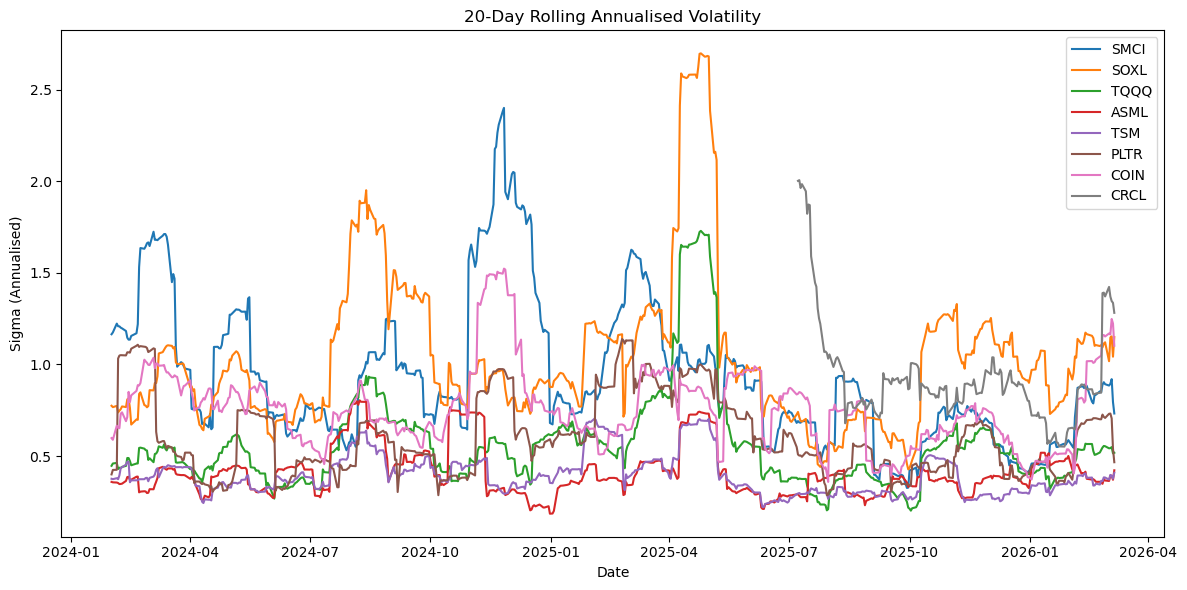

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

rolling_window = 20
DATA_DIR = Path.cwd() / "reversal_data"


def plot_rolling_sigma(ticker_list, win=rolling_window, ann_factor=252):

    """
    Plot rolling annualised sigma using CSV data from reversal_data.
    """

    plt.figure(figsize=(12,6))
    failed=[]

    for tic in ticker_list:

        try:

            file_path = DATA_DIR / f"{tic}.csv"

            if not file_path.exists():
                raise FileNotFoundError(f"{file_path} not found")

            df = pd.read_csv(file_path)

            df.columns = (
                df.columns
                .str.replace(r'[\xa0\u3000\t]', ' ', regex=True)
                .str.strip()
            )

            df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
            df["Adj Close"] = pd.to_numeric(df["Adj Close"], errors="coerce")

            df = df.sort_values("Date").reset_index(drop=True)

            # log returns
            log_r = np.log(df["Adj Close"] / df["Adj Close"].shift(1))

            # rolling sigma
            roll_sig = log_r.rolling(win).std() * np.sqrt(ann_factor)

            plt.plot(df["Date"], roll_sig, label=tic)

        except Exception as e:

            failed.append(tic)
            print(f"{tic} failed -> {e}")

    if failed:
        print("Could not plot:", ", ".join(failed))

    plt.title(f"{win}-Day Rolling Annualised Volatility")
    plt.xlabel("Date")
    plt.ylabel("Sigma (Annualised)")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_rolling_sigma(["SMCI","SOXL","TQQQ", "ASML", "TSM", "PLTR", "COIN", "CRCL"])